# Q-Learning with Gymnasium MountainCar-v0
## Continuous-state discretization, Q-table learning, convergence, policy maps, and trained-agent animation

This notebook uses the **built-in Gymnasium `MountainCar-v0` environment**.

A car is trapped in a valley. Its engine is not powerful enough to drive directly up the right hill. The agent must learn to move back and forth, build momentum, and eventually reach the flag.

Unlike FrozenLake, Taxi, CliffWalking, and Blackjack, MountainCar has a **continuous observation space**.

Therefore, to use tabular Q-Learning we first discretize the continuous state into a finite grid.

This notebook includes:

- problem description;
- continuous state and discrete action definitions;
- state discretization;
- Q-Learning from scratch;
- first 60 Q-value updates;
- convergence graphs;
- the final learned discretized Q-table;
- value and policy maps;
- evaluation;
- an animation of the trained car in the real Gymnasium environment.

In [1]:
%pip install -q "gymnasium[classic-control]" imageio pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 57.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

import imageio.v2 as imageio
from IPython.display import Image as IPyImage, display

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_rows", 1000)
pd.set_option("display.max_columns", 20)

## 1. Problem Description

The car begins near the bottom of a valley.

The goal is to reach the flag on the right hill.

### Continuous State

The observation is

$$
S_t=(x_t,v_t),
$$

where:

- $x_t$ = car position;
- $v_t$ = car velocity.

Both are continuous variables.

### Actions

There are three discrete actions:

$$
\mathcal A=\{0,1,2\}
$$

with:

- $0=$ accelerate left;
- $1=$ no acceleration;
- $2=$ accelerate right.

### Reward

The standard environment gives

$$
R_{t+1}=-1
$$

for each time step until the episode terminates.

Therefore, maximizing return is equivalent to reaching the goal in as few steps as possible.

### Terminal Condition

The episode terminates when the car reaches the target position on the right hill.

### Key Difficulty

The car cannot reach the goal by simply accelerating right from the start.

It must first move left to gain potential energy, then reverse direction and use momentum.

Environment: MountainCar-v0
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Discrete(3)
Observation low: [-1.2  -0.07]
Observation high: [0.6  0.07]
Example initial state: [-0.475  0.   ]


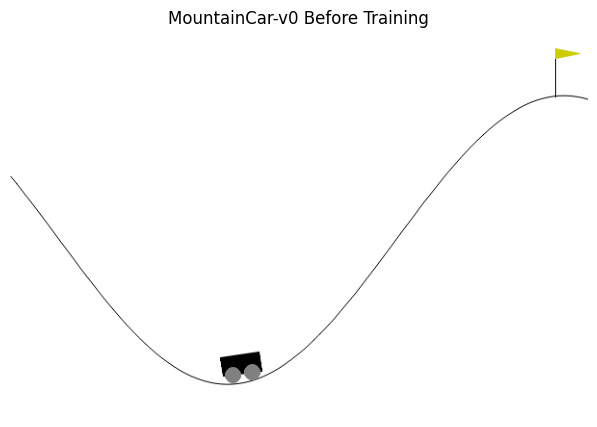

In [3]:
ENV_ID = "MountainCar-v0"
ACTION_NAMES = ["Accelerate Left", "No Acceleration", "Accelerate Right"]

env = gym.make(ENV_ID)
render_env = gym.make(ENV_ID, render_mode="rgb_array")

print("Environment:", ENV_ID)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Observation low:", env.observation_space.low)
print("Observation high:", env.observation_space.high)

state, info = render_env.reset(seed=7)
print("Example initial state:", state)

plt.figure(figsize=(9, 5))
plt.imshow(render_env.render())
plt.axis("off")
plt.title("MountainCar-v0 Before Training")
plt.show()

## 2. Why Discretization Is Required

A normal Q-table requires a finite state set.

MountainCar's state is continuous, so there are infinitely many possible values of

$$
(x,v).
$$

We divide the state space into bins.

In this notebook:

$$
N_x=24
$$

position bins and

$$
N_v=24
$$

velocity bins are used.

Therefore, the discretized state space contains

$$
24\times24=576
$$

states.

With three actions, the Q-table has

$$
576\times3=1728
$$

learned state-action values.

This is an approximation of the original continuous problem.

In [4]:
N_POSITION_BINS = 24
N_VELOCITY_BINS = 24

position_low, velocity_low = env.observation_space.low
position_high, velocity_high = env.observation_space.high

position_edges = np.linspace(
    position_low,
    position_high,
    N_POSITION_BINS + 1
)

velocity_edges = np.linspace(
    velocity_low,
    velocity_high,
    N_VELOCITY_BINS + 1
)

def discretize_state(observation):
    position, velocity = observation

    position_bin = np.digitize(
        position,
        position_edges[1:-1]
    )

    velocity_bin = np.digitize(
        velocity,
        velocity_edges[1:-1]
    )

    position_bin = int(np.clip(position_bin, 0, N_POSITION_BINS - 1))
    velocity_bin = int(np.clip(velocity_bin, 0, N_VELOCITY_BINS - 1))

    return position_bin, velocity_bin

example_state = np.array([-0.5, 0.02])
print("Continuous state:", example_state)
print("Discretized state:", discretize_state(example_state))

Continuous state: [-0.5   0.02]
Discretized state: (9, 15)


## 3. Q-Learning Update

After discretization, the standard Q-Learning update can be used:

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma\max_aQ(S_{t+1},a)
-
Q(S_t,A_t)
\right].
$$

Here, $S_t$ means the discretized pair

$$
S_t=(i_x,i_v).
$$

## 4. Train the Agent

Parameters used here are:

$$
\alpha=0.15,
\qquad
\gamma=0.99.
$$

Exploration follows a decaying $\epsilon$-greedy policy.

Because every nonterminal step gives reward $-1$, the episode return is directly related to the number of steps:

$$
G=-\text{episode length}.
$$

So improving return means reaching the flag faster.

In [5]:
def train_q_learning(
    n_episodes=20000,
    alpha=0.15,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.02,
    epsilon_decay=0.9995,
    seed=7
):
    rng = np.random.default_rng(seed)

    Q = np.zeros(
        (N_POSITION_BINS, N_VELOCITY_BINS, env.action_space.n),
        dtype=float
    )

    history = []
    update_log = []

    epsilon = epsilon_start
    update_number = 0

    for episode in range(1, n_episodes + 1):
        observation, _ = env.reset(seed=seed + episode)
        state = discretize_state(observation)

        total_reward = 0.0
        success = False
        max_abs_update = 0.0

        for step in range(1, 201):
            if rng.random() < epsilon:
                action = int(rng.integers(env.action_space.n))
                selection = "explore"
            else:
                q_values = Q[state]
                best_actions = np.flatnonzero(np.isclose(q_values, q_values.max()))
                action = int(rng.choice(best_actions))
                selection = "exploit"

            next_observation, reward, terminated, truncated, _ = env.step(action)
            next_state = discretize_state(next_observation)

            old_q = Q[state + (action,)]

            if terminated:
                max_next_q = 0.0
                target = reward
            else:
                max_next_q = np.max(Q[next_state])
                target = reward + gamma * max_next_q

            td_error = target - old_q
            update_amount = alpha * td_error

            Q[state + (action,)] += update_amount
            max_abs_update = max(max_abs_update, abs(update_amount))

            update_number += 1

            if update_number <= 60:
                update_log.append({
                    "Update": update_number,
                    "Episode": episode,
                    "Step": step,
                    "Position": observation[0],
                    "Velocity": observation[1],
                    "Position Bin": state[0],
                    "Velocity Bin": state[1],
                    "Action": ACTION_NAMES[action],
                    "Reward": reward,
                    "Next Position": next_observation[0],
                    "Next Velocity": next_observation[1],
                    "Old Q": old_q,
                    "Max Next Q": max_next_q,
                    "TD Target": target,
                    "TD Error": td_error,
                    "New Q": Q[state + (action,)],
                    "Epsilon": epsilon
                })

            total_reward += reward
            observation = next_observation
            state = next_state

            if terminated or truncated:
                success = bool(terminated)
                break

        history.append({
            "Episode": episode,
            "Return": total_reward,
            "Episode Length": step,
            "Success": int(success),
            "Epsilon": epsilon,
            "Max Absolute Q Update": max_abs_update
        })

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, pd.DataFrame(history), pd.DataFrame(update_log)

Q, history, update_log = train_q_learning()

print("Training complete.")
display(history.tail())

Training complete.


,Episode,Return,Episode Length,Success,Epsilon,Max Absolute Q Update
19995,19996,-200.0,200,0,0.02,1.408782
19996,19997,-147.0,147,1,0.02,3.049890
19997,19998,-142.0,142,1,0.02,3.268296
19998,19999,-141.0,141,1,0.02,2.740590
19999,20000,-145.0,145,1,0.02,1.093223


## 5. First 60 Q-Value Updates

The first 60 updates expose how continuous observations are converted into discrete bins before the Q-table is updated.

In [6]:
display(update_log.round(5))

,Update,Episode,Step,Position,Velocity,Position Bin,Velocity Bin,Action,Reward,Next Position,Next Velocity,Old Q,Max Next Q,TD Target,TD Error,New Q,Epsilon
0,1,1,1,-0.53461,0.00000,8,12,Accelerate Right,-1.0,-0.53352,0.00108,0.00000,0.00000,-1.00000,-1.00000,-0.15000,1.0
1,2,1,2,-0.53352,0.00108,8,12,Accelerate Right,-1.0,-0.53137,0.00216,-0.15000,0.00000,-1.00000,-0.85000,-0.27750,1.0
2,3,1,3,-0.53137,0.00216,8,12,Accelerate Left,-1.0,-0.53015,0.00122,0.00000,0.00000,-1.00000,-1.00000,-0.15000,1.0
3,4,1,4,-0.53015,0.00122,8,12,Accelerate Left,-1.0,-0.52989,0.00026,-0.15000,0.00000,-1.00000,-0.85000,-0.27750,1.0
4,5,1,5,-0.52989,0.00026,8,12,No Acceleration,-1.0,-0.52958,0.00031,0.00000,0.00000,-1.00000,-1.00000,-0.15000,1.0
5,6,1,6,-0.52958,0.00031,8,12,Accelerate Right,-1.0,-0.52822,0.00136,-0.27750,-0.15000,-1.14850,-0.87100,-0.40815,1.0
6,7,1,7,-0.52822,0.00136,8,12,Accelerate Right,-1.0,-0.52583,0.00239,-0.40815,-0.15000,-1.14850,-0.74035,-0.51920,1.0
7,8,1,8,-0.52583,0.00239,8,12,Accelerate Left,-1.0,-0.52442,0.00141,-0.27750,0.00000,-1.00000,-0.72250,-0.38588,1.0
8,9,1,9,-0.52442,0.00141,9,12,Accelerate Right,-1.0,-0.52201,0.00241,0.00000,0.00000,-1.00000,-1.00000,-0.15000,1.0
9,10,1,10,-0.52201,0.00241,9,12,No Acceleration,-1.0,-0.51960,0.00240,0.00000,0.00000,-1.00000,-1.00000,-0.15000,1.0


## 6. Convergence Graph: Moving Average Episode Length

Because each step gives reward $-1$, episode length is a useful performance measure.

A shorter episode means the car reached the goal more quickly.

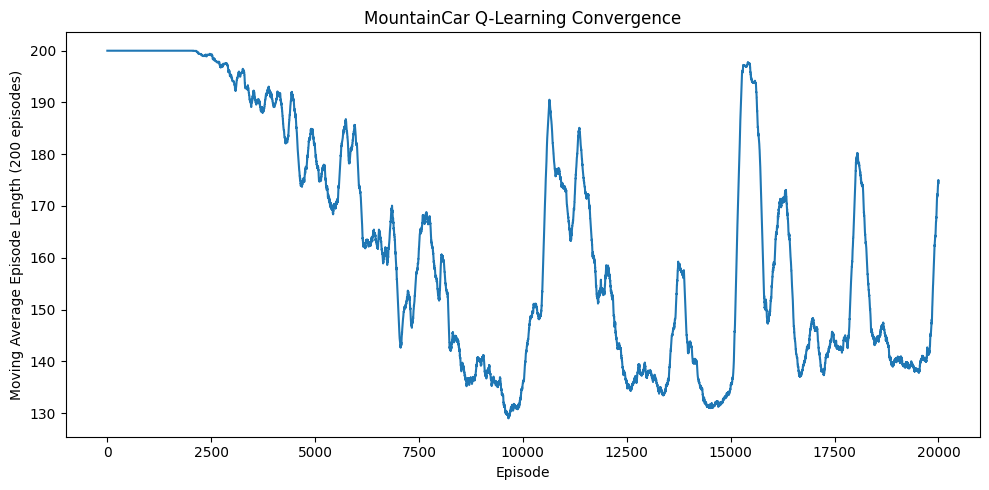

In [7]:
window = 200

history["Moving Average Episode Length"] = (
    history["Episode Length"]
    .rolling(window, min_periods=1)
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(
    history["Episode"],
    history["Moving Average Episode Length"]
)
plt.xlabel("Episode")
plt.ylabel(f"Moving Average Episode Length ({window} episodes)")
plt.title("MountainCar Q-Learning Convergence")
plt.tight_layout()
plt.show()

## 7. Success Rate During Training

The next graph shows the moving success rate.

A success means the agent reached the flag before the environment time limit.

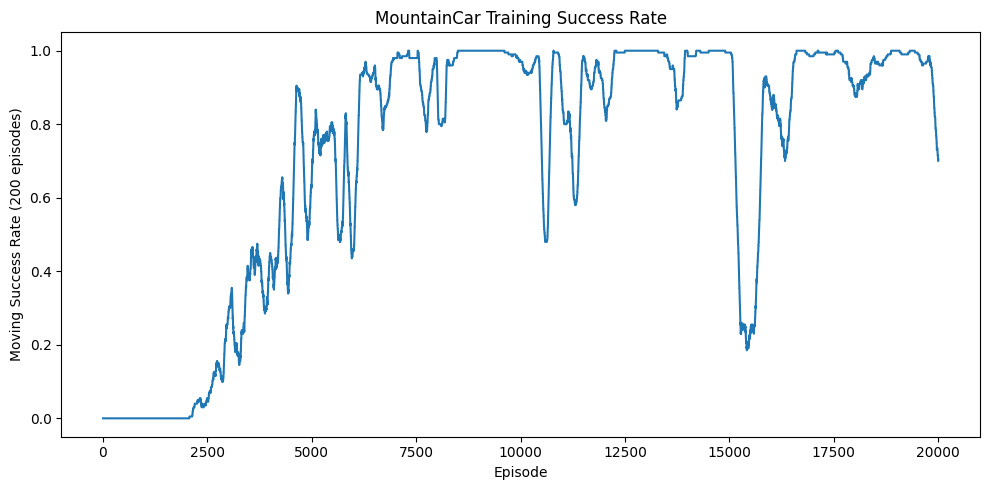

In [8]:
history["Moving Success Rate"] = (
    history["Success"]
    .rolling(window, min_periods=1)
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(
    history["Episode"],
    history["Moving Success Rate"]
)
plt.xlabel("Episode")
plt.ylabel(f"Moving Success Rate ({window} episodes)")
plt.title("MountainCar Training Success Rate")
plt.tight_layout()
plt.show()

## 8. Q-Value Update Magnitude

A second convergence indicator is the largest absolute Q-value change within each episode.

As learning stabilizes, the updates generally become smaller.

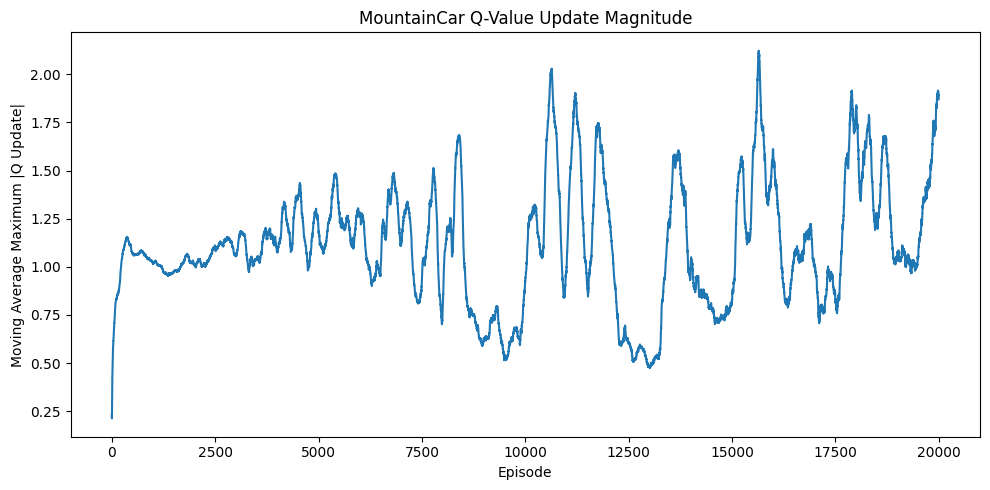

In [9]:
history["Moving Average Max Q Update"] = (
    history["Max Absolute Q Update"]
    .rolling(window, min_periods=1)
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(
    history["Episode"],
    history["Moving Average Max Q Update"]
)
plt.xlabel("Episode")
plt.ylabel("Moving Average Maximum |Q Update|")
plt.title("MountainCar Q-Value Update Magnitude")
plt.tight_layout()
plt.show()

## 9. Final Learned Q-Table

For MountainCar there is no exact finite Q-table for the original continuous state space.

The table below is therefore the **learned action-value table for the 24×24 discretized representation**.

Each row corresponds to one discretized pair:

$$
(\text{position bin},\text{velocity bin}).
$$

In [10]:
q_rows = []

for p_bin in range(N_POSITION_BINS):
    for v_bin in range(N_VELOCITY_BINS):
        q_rows.append({
            "Position Bin": p_bin,
            "Velocity Bin": v_bin,
            "Q(Accelerate Left)": Q[p_bin, v_bin, 0],
            "Q(No Acceleration)": Q[p_bin, v_bin, 1],
            "Q(Accelerate Right)": Q[p_bin, v_bin, 2],
            "Greedy Action": ACTION_NAMES[np.argmax(Q[p_bin, v_bin])]
        })

q_table_df = pd.DataFrame(q_rows)

print("Final learned discretized Q-table:")
display(q_table_df.round(4))

Final learned discretized Q-table:


,Position Bin,Velocity Bin,Q(Accelerate Left),Q(No Acceleration),Q(Accelerate Right),Greedy Action
0,0,0,0.0000,0.0000,0.0000,Accelerate Left
1,0,1,0.0000,0.0000,0.0000,Accelerate Left
2,0,2,-37.6879,-37.0895,-37.7812,No Acceleration
3,0,3,-36.2216,-38.3280,-38.5165,Accelerate Left
4,0,4,-37.2674,-39.1397,-39.1640,Accelerate Left
5,0,5,-36.4854,-39.0735,-39.5161,Accelerate Left
6,0,6,-39.6292,-37.1531,-39.6402,No Acceleration
7,0,7,-39.6966,-40.4505,-37.6208,Accelerate Right
8,0,8,-38.7929,-38.6483,-38.6766,No Acceleration
9,0,9,-38.7701,-38.7980,-38.5068,Accelerate Right


## 10. State-Value Map

The best learned Q-value in each discretized state is

$$
V(s)=\max_aQ(s,a).
$$

The heatmap shows how the learned value changes with position and velocity.

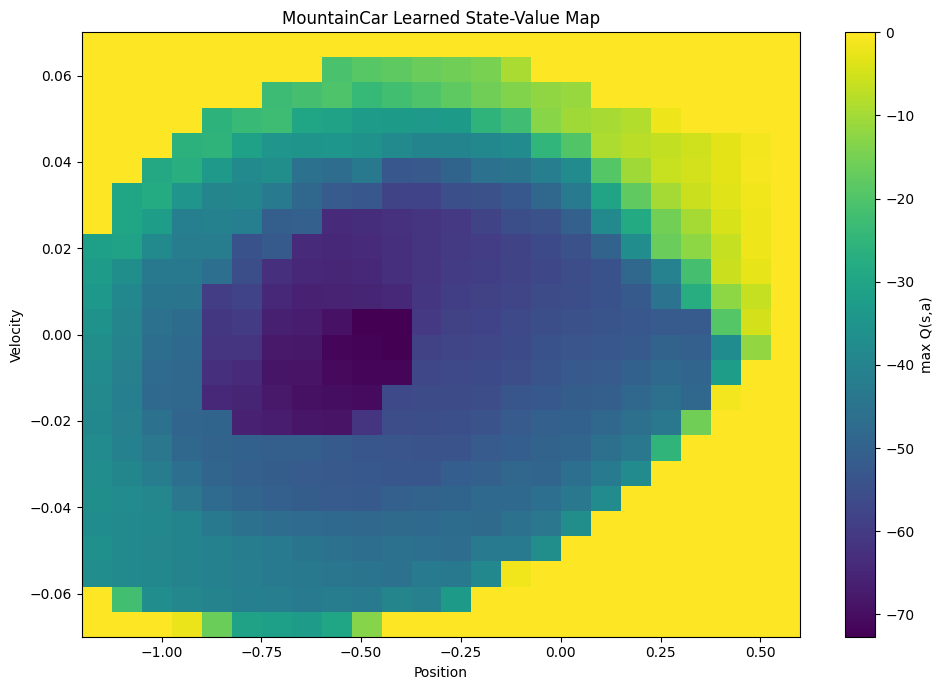

In [11]:
V = np.max(Q, axis=2)

plt.figure(figsize=(10, 7))
plt.imshow(
    V.T,
    origin="lower",
    aspect="auto",
    extent=[
        position_low,
        position_high,
        velocity_low,
        velocity_high
    ]
)
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("MountainCar Learned State-Value Map")
plt.colorbar(label="max Q(s,a)")
plt.tight_layout()
plt.show()

## 11. Greedy Policy Map

The optimal action under the learned discretized Q-table is

$$
\pi(s)=\arg\max_aQ(s,a).
$$

The map uses:

- $0=$ accelerate left;
- $1=$ no acceleration;
- $2=$ accelerate right.

This makes it possible to see when the agent chooses to reverse direction to build momentum.

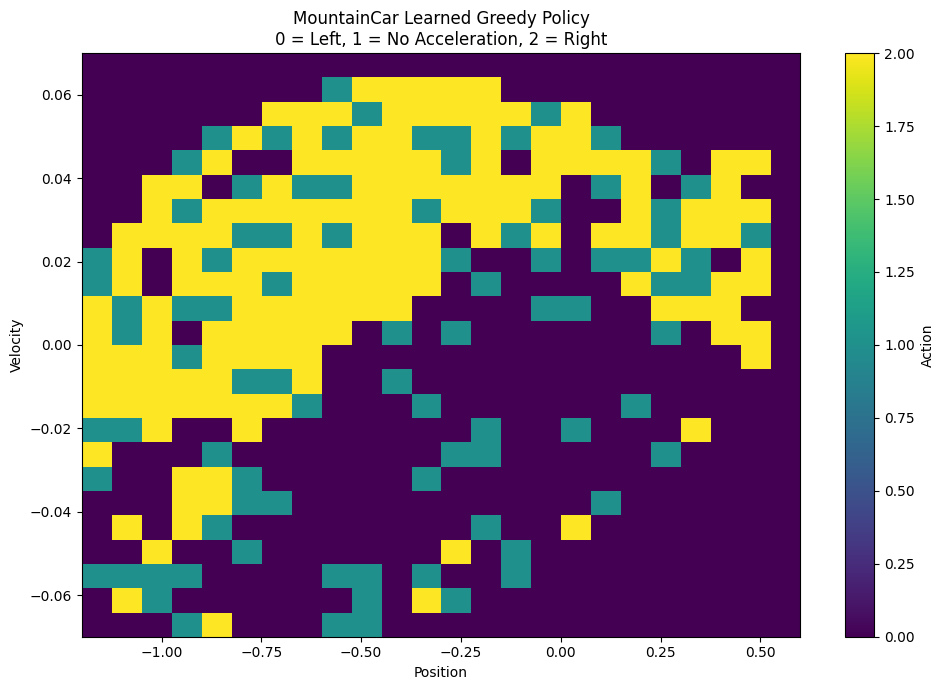

In [12]:
policy = np.argmax(Q, axis=2)

plt.figure(figsize=(10, 7))
plt.imshow(
    policy.T,
    origin="lower",
    aspect="auto",
    extent=[
        position_low,
        position_high,
        velocity_low,
        velocity_high
    ],
    vmin=0,
    vmax=2
)
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("MountainCar Learned Greedy Policy\n0 = Left, 1 = No Acceleration, 2 = Right")
plt.colorbar(label="Action")
plt.tight_layout()
plt.show()

## 12. Evaluate the Trained Agent

The learned greedy policy is evaluated without exploration.

In [13]:
def evaluate_agent(Q, n_episodes=200, seed=50000):
    returns = []
    lengths = []
    successes = 0

    for episode in range(n_episodes):
        observation, _ = env.reset(seed=seed + episode)
        state = discretize_state(observation)
        total_reward = 0.0

        for step in range(1, 201):
            action = int(np.argmax(Q[state]))

            observation, reward, terminated, truncated, _ = env.step(action)
            state = discretize_state(observation)

            total_reward += reward

            if terminated or truncated:
                successes += int(terminated)
                break

        returns.append(total_reward)
        lengths.append(step)

    return pd.DataFrame([{
        "Episodes": n_episodes,
        "Success Rate": successes / n_episodes,
        "Mean Return": np.mean(returns),
        "Mean Episode Length": np.mean(lengths),
        "Best Episode Length": np.min(lengths)
    }])

evaluation = evaluate_agent(Q)
display(evaluation.round(3))

,Episodes,Success Rate,Mean Return,Mean Episode Length,Best Episode Length
0,200,0.52,-183.565,183.565,133


## 13. Run the Trained Agent in MountainCar-v0

The following cell uses the actual Gymnasium renderer.

The trained greedy agent is run without exploration, its frames are collected, and the result is shown as a GIF inside Colab.

Steps: 195
Total reward: -195.0
Reached goal: True


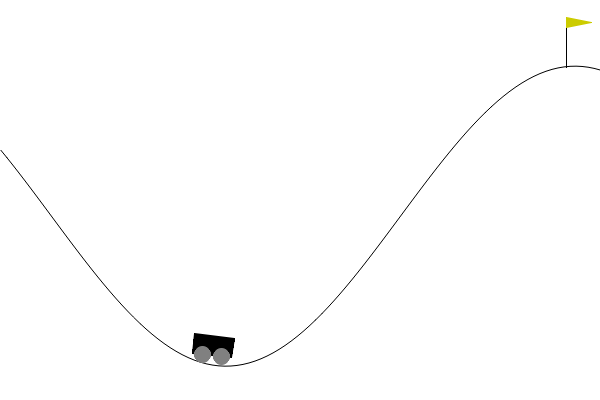

In [14]:
def save_gif(frames, filename, duration=0.04):
    imageio.mimsave(filename, frames, duration=duration, loop=0)
    display(IPyImage(filename=filename))

def record_trained_agent(Q, filename="mountaincar_trained_agent.gif", seed=2026):
    frames = []

    observation, _ = render_env.reset(seed=seed)
    state = discretize_state(observation)
    frames.append(render_env.render())

    total_reward = 0.0
    actions = []

    for step in range(1, 201):
        action = int(np.argmax(Q[state]))
        actions.append(action)

        observation, reward, terminated, truncated, _ = render_env.step(action)
        state = discretize_state(observation)

        total_reward += reward
        frames.append(render_env.render())

        if terminated or truncated:
            break

    print("Steps:", step)
    print("Total reward:", total_reward)
    print("Reached goal:", bool(terminated))

    save_gif(frames, filename, duration=0.04)

record_trained_agent(Q)

## 14. Why MountainCar Is Useful in a Q-Learning Portfolio

MountainCar adds an important idea that the purely discrete environments do not show:

$$
\boxed{
\text{continuous observation}
\rightarrow
\text{discretization}
\rightarrow
\text{tabular Q-Learning}
}
$$

It also demonstrates a non-obvious learned behavior.

The best immediate-looking action is not enough. The car has to move away from the goal temporarily so that it can build momentum and achieve a larger long-term return.

## 15. Limitation of the Tabular Approach

The discretization loses information.

Two slightly different continuous states can fall into the same bin and therefore share the same Q-values.

Increasing the number of bins improves resolution but also increases the size of the Q-table.

This limitation motivates function approximation methods such as **Deep Q-Networks (DQN)**, where a neural network approximates

$$
Q(s,a)
$$

instead of storing one value for every discrete state-action pair.